# SAM3 pipeline debug notebook (steps 1 to 3)

This notebook runs:
1. Pipeline step 1: dataset inference + concept map
2. Pipeline step 2: crops JSON creation with SAM3
3. Pipeline step 3: feature generation

Then it runs a focused `crops_to_json.py` demo for one tag and one image directory so you can inspect segmentation patch creation.

In [15]:
from pathlib import Path
import json
import os
import sys

# --- Direct SAM3 input ---
ROOT_DIR = Path('/mnt/abka03/Projects/xl-vlms')
INPUT_DIR = Path('/mnt/abka03/xlvlm_data/Norwegen2024')
OUTPUT_DIR = ROOT_DIR / 'outputs' / 'sam3_debug'

# Set the images to segment and the tag prompt to use
IMAGE_PATHS = [
    Path('/mnt/abka03/xlvlm_data/Norwegen2024/20240422_094445.jpg'),
    Path('/mnt/abka03/xlvlm_data/Norwegen2024/20240419_192751.jpg'),
]
TAG_NAME = 'blue'
IMAGE_SIZE_WIDTH = 512
# SAM3 knobs
DEVICE = 'cuda:0'
BOX_THRESHOLD = 0.1
DETECTION_BATCH_SIZE = 2
CONCEPT_MASKS_PER_IMAGE = 1

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('ROOT_DIR  :', ROOT_DIR)
print('INPUT_DIR :', INPUT_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('IMAGE_PATHS:')
for p in IMAGE_PATHS: print('  -', p)
print('TAG_NAME  :', TAG_NAME)

ROOT_DIR  : /mnt/abka03/Projects/xl-vlms
INPUT_DIR : /mnt/abka03/xlvlm_data/Norwegen2024
OUTPUT_DIR: /mnt/abka03/Projects/xl-vlms/outputs/sam3_debug
IMAGE_PATHS:
  - /mnt/abka03/xlvlm_data/Norwegen2024/20240422_094445.jpg
  - /mnt/abka03/xlvlm_data/Norwegen2024/20240419_192751.jpg
TAG_NAME  : blue


In [16]:
def _ensure_repo_root_on_sys_path():
    repo_root = str(ROOT_DIR)
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    return repo_root


def load_image_path(image_path: Path) -> Path:
    if not image_path.is_file():
        raise FileNotFoundError(f'Image not found: {image_path}')
    return image_path


print('Direct SAM3 flow is ready. Run the next cell to segment IMAGE_PATH with TAG_NAME.')

Direct SAM3 flow is ready. Run the next cell to segment IMAGE_PATH with TAG_NAME.


Loading SAM3 model...
SAM3 loaded
Loading and resizing '20240422_094445.jpg'...
Loading and resizing '20240419_192751.jpg'...
Running detect_concept_masks for tag 'blue' on 2 images...


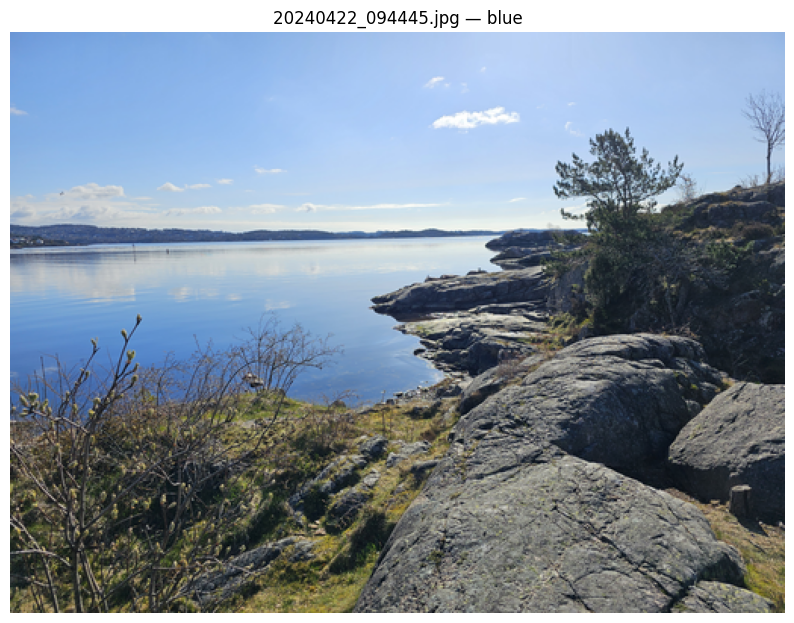

Concept masks detected for 20240422_094445.jpg: 0


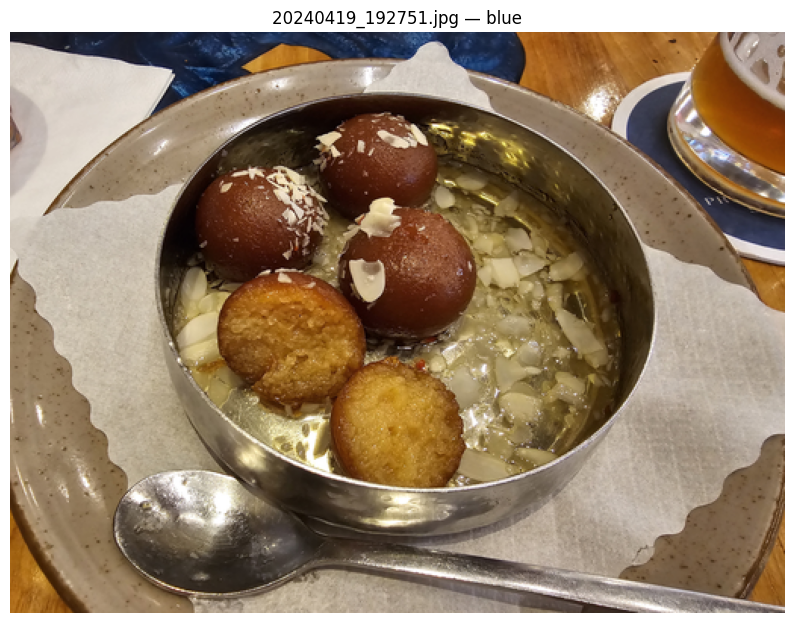

Concept masks detected for 20240419_192751.jpg: 0


In [17]:
# Direct SAM3 segmentation for a small list of user-provided images and a tag using crops_to_json helpers.
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

_ensure_repo_root_on_sys_path()
from preprocessing.crops_to_json import _load_sam3, _load_and_resize, detect_concept_masks

image_paths = [load_image_path(p) for p in IMAGE_PATHS]

print('Loading SAM3 model...')
model = _load_sam3(device=DEVICE, confidence_threshold=BOX_THRESHOLD)
print('SAM3 loaded')

pil_images = []
for image_path in image_paths:
    print(f'Loading and resizing {image_path.name!r}...')
    img, (w, h), _ = _load_and_resize(str(image_path), IMAGE_SIZE_WIDTH)
    pil_images.append(img)

print(f'Running detect_concept_masks for tag {TAG_NAME!r} on {len(pil_images)} images...')
pairs_per_img = detect_concept_masks(
    pil_images,
    tag=TAG_NAME,
    detector='sam3',
    model=model,
    batch_size=DETECTION_BATCH_SIZE,
    concept_masks_per_image=CONCEPT_MASKS_PER_IMAGE,
 )

for image_path, img, pairs in zip(image_paths, pil_images, pairs_per_img):
    pairs = pairs or []
    img_np = np.array(img)
    overlay = img_np.copy().astype(np.float32)
    for idx, (bbox, mask) in enumerate(pairs):
        if mask is None:
            continue
        mask_bool = mask.astype(bool)
        if mask_bool.shape[:2] != img_np.shape[:2]:
            mask_bool = np.array(
                Image.fromarray((mask_bool > 0).astype(np.uint8) * 255).resize(
                    (img_np.shape[1], img_np.shape[0]), Image.NEAREST
)
) > 127
        overlay = np.where(mask_bool[..., None], 0.75 * overlay + 0.25 * np.array([0, 255, 0]), overlay)
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(overlay.astype(np.uint8))
    ax.set_title(f'{image_path.name} — {TAG_NAME}')
    ax.axis('off')
    for jdx, (bbox, mask) in enumerate(pairs):
        x, y, w, h = [int(v) for v in bbox]
        rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor='lime', linewidth=2)
        ax.add_patch(rect)
        ax.text(x, max(0, y - 4), f"{jdx}: concept=True", color='lime', fontsize=8, backgroundcolor='black')
    plt.show()
    print(f'Concept masks detected for {image_path.name}: {len(pairs)}')

In [ ]:
# Display ALL images from the crops JSON with RLE mask overlays.
# Set SHOW_ONLY_CONCEPTS = True to display only concept masks
import json
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import sys

# ensure repo imports are available
sys.path.insert(0, str(ROOT_DIR))
from src.mask_utils import decode_mask_rle

# Load crops JSON produced earlier
with open(single_tag_crops_json, 'r', encoding='utf-8') as f:
    crops = json.load(f)

records = crops.get(TAG_NAME, {})
if not records:
    raise ValueError(f'No records for tag={TAG_NAME!r} in {single_tag_crops_json}')

# Toggle this to show only concept masks
SHOW_ONLY_CONCEPTS = True

def visualize_record(rel_path, record, show_bboxes=True, alpha=0.25, show_only_concepts=False):
    img_path = INPUT_DIR / rel_path
    img = Image.open(img_path).convert('RGB')
    img_np = np.array(img)
    out = img_np.copy().astype(np.float32)

    masks_all = record.get('masks_rle', [])
    masks = [m for m in masks_all if (not show_only_concepts) or m.get('is_concept', False)]

    for i, m in enumerate(masks):
        rle = m.get('rle')
        if rle is None:
            continue
        mask = decode_mask_rle(rle)
        # resize mask to image if needed
        if mask.shape[:2] != img_np.shape[:2]:
            mask = np.array(Image.fromarray((mask > 0).astype(np.uint8) * 255)
                            .resize((img_np.shape[1], img_np.shape[0]), Image.NEAREST)) > 127
        color = np.array([0, 255, 0]) if m.get('is_concept', False) else np.array([255, 0, 0])
        out = np.where(mask[..., None], (1 - alpha) * out + alpha * color, out)

    out = out.astype(np.uint8)
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(out)
    ax.set_title(f'{rel_path} — {TAG_NAME}')
    ax.axis('off')

    if show_bboxes:
        for i, m in enumerate(masks):
            bbox = m.get('bbox', [0, 0, 1, 1])
            x, y, w, h = [int(v) for v in bbox]
            color = 'lime' if m.get('is_concept', False) else 'red'
            rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=2)
            ax.add_patch(rect)
            ax.text(x, max(0, y - 4), f"{i}: concept={m.get('is_concept', False)}",
                    color=color, fontsize=8, backgroundcolor='black')
    plt.show()

# Iterate and show all records. If there are many images this will display them sequentially.
for idx, (rel_path, record) in enumerate(records.items(), start=1):
    print(f'[{idx}/{len(records)}] Showing: {rel_path}')
    visualize_record(rel_path, record, show_only_concepts=SHOW_ONLY_CONCEPTS)

print('Done.')

: 